# Create Imbalance Data set

In [4]:
from sklearn.datasets import make_classification
import pandas as pd

# create synthetic imbalanced data
X, y = make_classification(
    n_samples = 1000, 
    n_features = 2, 
    n_redundant = 0, 
    n_clusters_per_class = 1,
    weights=[0.99],
    flip_y=0,
    random_state=42    
)

# Check distribution
print(pd.Series(y).value_counts())


0    990
1     10
Name: count, dtype: int64


# Train a Model 

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# split the resampled data into training and test
X_train, X_test, y_train, y_test = train_test_split(
                                                X, 
                                                y, 
                                                test_size = 0.3, 
                                                random_state = 42,
                                                stratify = y
                                            )
# initilize and Train a Model
model = LogisticRegression(random_state= 42)
model.fit(X_train, y_train)

# Make prediction on test set
y_pred = model.predict(X_test)

# Eveluate 
print("Accuracy on Imbalanced Data Set:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9933333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       297
           1       1.00      0.33      0.50         3

    accuracy                           0.99       300
   macro avg       1.00      0.67      0.75       300
weighted avg       0.99      0.99      0.99       300



n_samples = 1000 : Generate 1000 samples 
n_features = 2 : Each samples will have 2 features(columns)  
n_redundant = 0 : There are no redundant features
n_clusters_per_class = 1 : Each Class will have one cluster data point.
weights=[0.99] : This is crucial for creating imbalance datasets. Class 0=99%, 1%=Class 1
flip_y=0 : No labels are randomly flipped. Ensure imbalancespecified by weights.
random_state=42 : Will get the exact same datasets. 

# Imbalanced data to Balance Data by SMOTE

# SMOTE

In [6]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [7]:
from imblearn.over_sampling import SMOTE

# Initilize SMOKE
smote = SMOTE(random_state=42 )

# Apply SMOTE to the imbalance dataset
X_resampled, y_resampled = smote.fit_resample(X,y)

# Check the Old Distribution
print("Original Distribution:")
print(pd.Series(y).value_counts())

# Check the New Distribution
print("\nResampled Distribution with SMOTE:")
print(pd.Series(y_resampled).value_counts())

Original Distribution:
0    990
1     10
Name: count, dtype: int64

Resampled Distribution with SMOTE:
0    990
1    990
Name: count, dtype: int64


# Visualize Imbalance and Balance data set

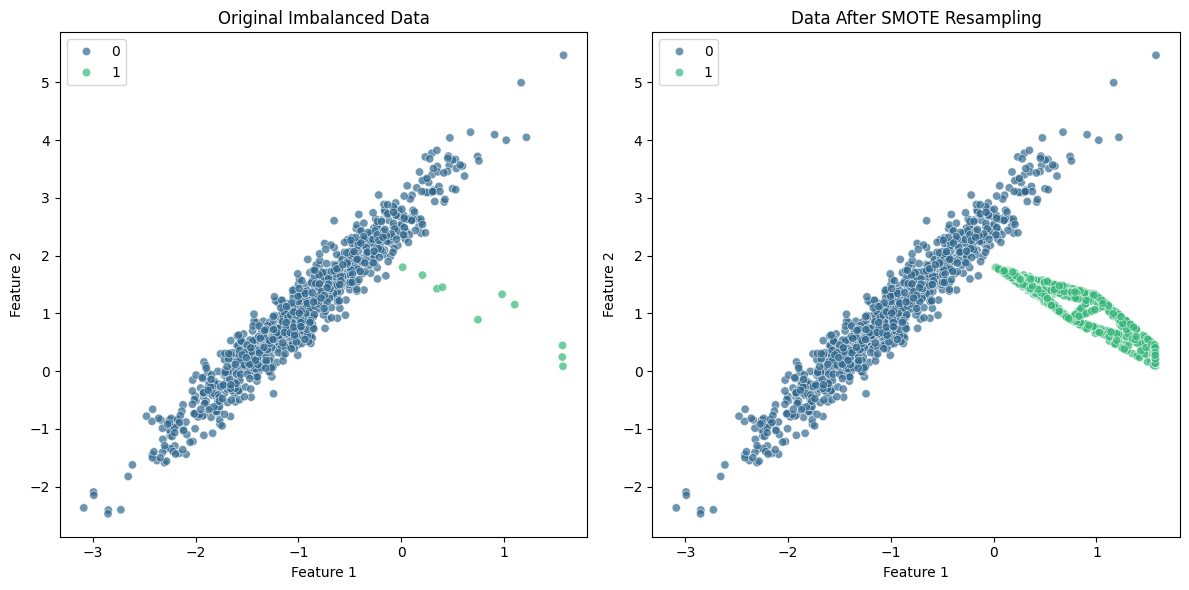

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

# plot the original data
plt.subplot(1,2,1)  # 1 row, 2 column, first plot
sns.scatterplot(x=X[:,0], y=X[:,1], hue = y, palette = 'viridis', alpha =0.7)
plt.title("Original Imbalanced Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Plot SMOKE resampled data
plt.subplot(1,2,2)  # 1 row, 2 column, first plot
sns.scatterplot(x=X_resampled[:,0], y=X_resampled[:,1], hue = y_resampled, palette = 'viridis', alpha =0.7)
plt.title("Data After SMOTE Resampling")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

# Train a Model with Balance data

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# split the resampled data into training and test
X_train, X_test, y_train, y_test = train_test_split(
                                                X_resampled, 
                                                y_resampled, 
                                                test_size = 0.3, 
                                                random_state = 42,
                                                stratify = y_resampled
                                            )
# initilize and Train a Model
model = LogisticRegression(random_state= 42)
model.fit(X_train, y_train)

# Make prediction on test set
y_pred = model.predict(X_test)

# Eveluate 
print("Accuracy on Balanced(SMOTE) Data Set:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy on Balanced(SMOTE) Data Set: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       297
           1       1.00      1.00      1.00       297

    accuracy                           1.00       594
   macro avg       1.00      1.00      1.00       594
weighted avg       1.00      1.00      1.00       594



# Home Work
## Credit Card Fraud Detection 
1. Data set from Kaggle
2. Train a Model
6. Evaluate the Model
3. Check Imbalance
4. Apply SMOTE
5. Visualze Imbalance and Balance Data set
6. Train a Model
7. Evaluate the Model